# Plots for combined eddy data (AC & C) and difference in atmospheric parameters

plots of different atmospheric parameters change with difference in sst

#### Data Import

In [1]:
import intake
import numpy as np
import matplotlib.pylab as plt
import xarray as xr
import matplotlib.colors as colors
from shapely.geometry import Polygon, Point, box
from shapely import contains_xy
import time
from scipy.stats import linregress
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
#import combo data fro combined AC/C eddies with r > q75 and e < 20%
edso1_dn23_clt_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_clt_q75_e20.nc")
edso1_dn23_hfls_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfls_q75_e20.nc")
edso1_dn23_hfss_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_hfss_q75_e20.nc")
edso1_dn23_sfcwind_q75_e20 = xr.open_dataset("/scratch/b/b383696/eddy_data/oceanS60/edso1_23/seaice3R/edso1_dn23_sfcwind_q75_e20.nc")

#### DOF Method

In [27]:
import numpy as np
import statsmodels.api as sm
from scipy import stats

def run_effective_regression(ds, y_name, x_name, T=7, alpha=0.05):
    """
    - compute effective sample size (n_eff = n / T)
    - simple linear regression y ~ x
    - compute Pearson r and R²
    - return full OLS output
    - adjust SE, t, p, CI using n_eff
    - print results rounded to 4 decimals
    """

    #data extraction
    ds_single = ds.isel(NbSample=0)
    df = ds_single.to_dataframe().reset_index()

    y = df[y_name]
    X = df[[x_name]]
    X = sm.add_constant(X)

    #effective sample size
    n = len(df)
    n_eff = n / T

    #OLS model
    model = sm.OLS(y, X).fit()
    ols_summary_text = model.summary().as_text()

    
    #pearson correlation and R²
    df_clean = df[[x_name, y_name]].dropna()
    r = np.corrcoef(df_clean[x_name], df_clean[y_name])[0, 1]

    R2 = r**2

    #adjust inference
    b = model.params[x_name]
    se_orig = model.bse[x_name]
    k = X.shape[1]

    se_new = se_orig * np.sqrt(n / n_eff)
    t_new = b / se_new
    df_eff = n_eff - k
    p_new = 2 * (1 - stats.t.cdf(abs(t_new), df=df_eff))

    tcrit = stats.t.ppf(1 - alpha/2, df=df_eff)
    ci_low = b - tcrit * se_new
    ci_high = b + tcrit * se_new

    #correlation significance
    t_r = r * np.sqrt((n_eff - 2) / (1 - r**2))
    p_r = 2 * (1 - stats.t.cdf(abs(t_r), df=n_eff - 2))

    #print results
    print("\n===== OLS RESULTS (raw) =====")
    print(ols_summary_text)
    
    print("\n===== EFFECTIVE SAMPLE SIZE =====")
    print(f"n      = {n}")
    print(f"n_eff  = {n_eff:.4f}")
    
    print("\n===== CORRELATION =====")
    print(f"r      = {r:.4f}")
    print(f"R²     = {R2:.4f}")
    print(f"t_r    = {t_r:.4f}")
    print(f"p_r    = {p_r:.4f}")
    
    print("\n===== REGRESSION COEFFICIENT (adjusted for n_eff) =====")
    
    # CI half-width for ± notation
    ci_half_width = (ci_high - ci_low) / 2
    
    print(f"beta (± CI)    = {b:.4f} ± {ci_half_width:.4f}")
    #print(f"SE original    = {se_orig:.4f}")
    print(f"SE adjusted    = {se_new:.4f}")
    #print(f"t original     = {model.tvalues[x_name]:.4f}")
    print(f"t adjusted     = {t_new:.4f}")
    #print(f"p original     = {model.pvalues[x_name]:.4f}")
    print(f"p adjusted     = {p_new:.4f}")
    print(f"CI adjusted    = [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"df_eff         = {df_eff:.4f}")

    #return results    
    return {
        "n": n,
        "n_eff": n_eff,
        "beta_original": b,
        "se_original": se_orig,
        "t_original": model.tvalues[x_name],
        "p_original": model.pvalues[x_name],
        "ci_original": model.conf_int().loc[x_name].tolist(),
        "beta": b,
        "se_adjusted": se_new,
        "t_adjusted": t_new,
        "p_adjusted": p_new,
        "ci_adjusted": (ci_low, ci_high),
        "df_eff": df_eff,
        "r": r,
        "t_r_adjusted": t_r,
        "p_r_adjusted": p_r,
        "R2": R2,
        "ols_summary": ols_summary_text,
        "model": model
    }


In [31]:
results = run_effective_regression(
    edso1_dn23_hfls_q75_e20,
    y_name="dif_hfls",
    x_name="dif_sst",
    T=7
)



===== OLS RESULTS (raw) =====
                            OLS Regression Results                            
Dep. Variable:               dif_hfls   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                 1.886e+04
Date:                Sat, 24 Jan 2026   Prob (F-statistic):               0.00
Time:                        18:49:56   Log-Likelihood:            -1.7799e+05
No. Observations:               60786   AIC:                         3.560e+05
Df Residuals:                   60784   BIC:                         3.560e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0646

In [7]:
#calculate effective size with T = 7
#n_eff = n/T

n = edso1_dn23_clt_q75_e20.sizes['obs']
n_eff = n / 7
print(f"Effective sample size (n_eff) = {n_eff:.1f}")

Effective sample size (n_eff) = 8683.7


In [6]:
import numpy as np

def weekly_random_subsample(ds, var_filter, obs_dim="obs", time_dim="time", seed=None):

    ds_flat = ds.isel(NbSample=0)

    if seed is not None:
        np.random.seed(seed)
        
    # Drop observations with NaNs in dif_sst or var_filter
    ds_clean = ds_flat.where(
        np.isfinite(ds_flat["dif_sst"]) &
        np.isfinite(ds_flat[var_filter]),
        drop=True
    )

    # Weekly binning
    time_vals = ds_clean[time_dim].values
    time_min = time_vals.min()

    week_bin = (
        (time_vals - time_min) / np.timedelta64(1, "D") // 7
    ).astype(int)

    # Randomly select one obs per week
    selected_indices = []

    for w in np.unique(week_bin):
        indices_in_bin = np.where(week_bin == w)[0]
        chosen_idx = np.random.choice(indices_in_bin, size=1)[0]
        selected_indices.append(chosen_idx)

    # Subset dataset
    ds_week = ds_clean.isel({obs_dim: selected_indices})

    print(seed)

    return ds_week



In [7]:
import numpy as np

def weekly_random_subsample_bootstrap(ds, var_filter, obs_dim="obs", time_dim="time", seed=None):
    """
    One bootstrap draw:
    1) Randomly sample weekly blocks (with replacement)
    2) For each selected week, randomly pick one eddy
    3) Return the subsampled dataset
    """

    rng = np.random.default_rng(seed)

    # Flatten dataset
    ds_flat = ds.isel(NbSample=0)

    # Drop NaNs
    ds_clean = ds_flat.where(
        np.isfinite(ds_flat["dif_sst"]) &
        np.isfinite(ds_flat[var_filter]),
        drop=True
    )

    # Weekly binning
    time_vals = ds_clean[time_dim].values
    time_min = time_vals.min()
    week_bin = ((time_vals - time_min) / np.timedelta64(1, "D") // 7).astype(int)

    unique_weeks = np.unique(week_bin)
    n_weeks = len(unique_weeks)

    # ---------------------------------------------------------
    # 1) SAMPLE WEEKS WITH REPLACEMENT
    # ---------------------------------------------------------
    sampled_weeks = rng.choice(unique_weeks, size=n_weeks, replace=True)

    selected_indices = []

    # ---------------------------------------------------------
    # 2) FOR EACH SELECTED WEEK, PICK ONE RANDOM EDDY
    # ---------------------------------------------------------
    for w in sampled_weeks:
        indices_in_bin = np.where(week_bin == w)[0]
        if len(indices_in_bin) == 0:
            continue
        chosen_idx = rng.choice(indices_in_bin)
        selected_indices.append(chosen_idx)

    # ---------------------------------------------------------
    # 3) RETURN THE SUBSAMPLED DATASET
    # ---------------------------------------------------------
    ds_week = ds_clean.isel({obs_dim: selected_indices})

    print(f"Bootstrap draw seed = {seed}")

    return ds_week


In [159]:
edso1_dn23_clt_q75_e20_week = weekly_random_subsample(edso1_dn23_clt_q75_e20, "dif_clt")
edso1_dn23_hfls_q75_e20_week = weekly_random_subsample(edso1_dn23_hfls_q75_e20, "dif_hfls")
edso1_dn23_hfss_q75_e20_week = weekly_random_subsample(edso1_dn23_hfss_q75_e20, "dif_hfss")
edso1_dn23_sfcwind_q75_e20_week = weekly_random_subsample(edso1_dn23_sfcwind_q75_e20, "dif_sfcwind")

None
None
None
None


In [8]:
edso1_dn23_clt_q75_e20_week = weekly_random_subsample_bootstrap(edso1_dn23_clt_q75_e20, "dif_clt")
edso1_dn23_hfls_q75_e20_week = weekly_random_subsample_bootstrap(edso1_dn23_hfls_q75_e20, "dif_hfls")
edso1_dn23_hfss_q75_e20_week = weekly_random_subsample_bootstrap(edso1_dn23_hfss_q75_e20, "dif_hfss")
edso1_dn23_sfcwind_q75_e20_week = weekly_random_subsample_bootstrap(edso1_dn23_sfcwind_q75_e20, "dif_sfcwind")

Bootstrap draw seed = None
Bootstrap draw seed = None
Bootstrap draw seed = None
Bootstrap draw seed = None


#### Plot Scatter Plot

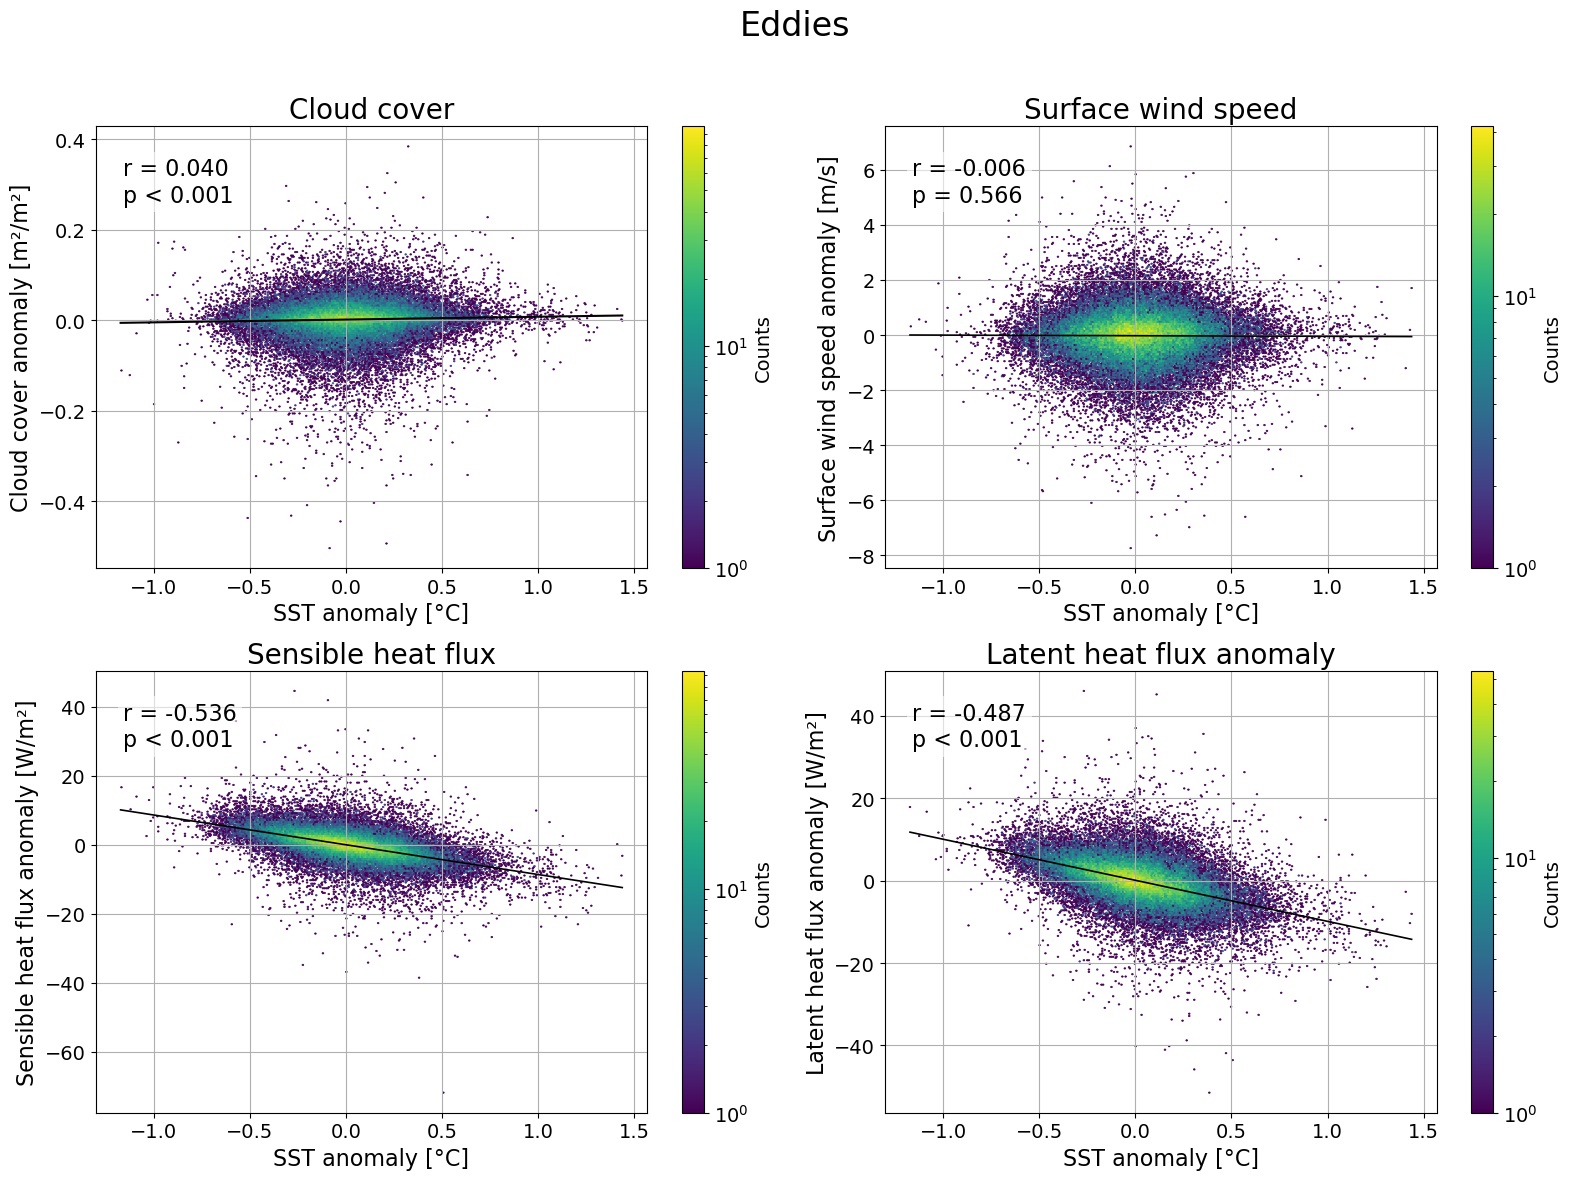

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=False)

#CLOUD COVER

ax = axes[0, 0]
x = edso1_dn23_clt_q75_e20.dif_sst
y = edso1_dn23_clt_q75_e20.dif_clt

mask = np.isfinite(x) & np.isfinite(y)
res = linregress(x[mask], y[mask])

hb = ax.hexbin(
    x, y,
    gridsize=300,
    cmap="viridis",
    norm=colors.LogNorm(),
    linewidths=0.5
)
cbar = fig.colorbar(hb, ax=ax, label="Counts")
cbar.ax.yaxis.label.set_size(14)
cbar.ax.tick_params(labelsize=14)

x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res.slope * x_fit + res.intercept, color="black", lw=1.5)

ax.text(
    0.05, 0.93,
    f"r = {res.rvalue:.3f}\np < 0.001",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax.set_xlabel("SST anomaly [°C]", fontsize = 16)
ax.set_ylabel("Cloud cover anomaly [m²/m²]", fontsize = 16)
ax.set_title("Cloud cover",fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True)


#SURFACE WIND

ax = axes[0, 1]
x = edso1_dn23_sfcwind_q75_e20.dif_sst
y = edso1_dn23_sfcwind_q75_e20.dif_sfcwind

mask = np.isfinite(x) & np.isfinite(y)
res = linregress(x[mask], y[mask])

hb = ax.hexbin(
    x, y,
    gridsize=300,
    cmap="viridis",
    norm=colors.LogNorm(),
    linewidths=0.5
)
cbar = fig.colorbar(hb, ax=ax, label="Counts")
cbar.ax.yaxis.label.set_size(14)
cbar.ax.tick_params(labelsize=14)

x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res.slope * x_fit + res.intercept, color="black", lw=1.2)

ax.text(
    0.05, 0.93,
    f"r = {res.rvalue:.3f}\np = 0.566",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)


ax.set_xlabel("SST anomaly [°C]", fontsize = 16)
ax.set_ylabel("Surface wind speed anomaly [m/s]", fontsize = 16)
ax.set_title("Surface wind speed",fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True)


# SENSIBLE HEAT FLUX

ax = axes[1, 0]
x = edso1_dn23_hfss_q75_e20.dif_sst
y = edso1_dn23_hfss_q75_e20.dif_hfss

mask = np.isfinite(x) & np.isfinite(y)
res = linregress(x[mask], y[mask])

hb = ax.hexbin(
    x, y,
    gridsize=300,
    cmap="viridis",
    norm=colors.LogNorm(),
    linewidths=0.5
)
cbar = fig.colorbar(hb, ax=ax, label="Counts")
cbar.ax.yaxis.label.set_size(14)
cbar.ax.tick_params(labelsize=14)

x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res.slope * x_fit + res.intercept, color="black", lw=1.2)

ax.text(
    0.05, 0.93,
    f"r = {res.rvalue:.3f}\np < 0.001",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)


ax.set_xlabel("SST anomaly [°C]", fontsize = 16)
ax.set_ylabel("Sensible heat flux anomaly [W/m²]", fontsize = 16)
ax.set_title("Sensible heat flux",fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True)


# LATENT HEAT FLUX

ax = axes[1, 1]
x = edso1_dn23_hfls_q75_e20.dif_sst
y = edso1_dn23_hfls_q75_e20.dif_hfls

mask = np.isfinite(x) & np.isfinite(y)
res = linregress(x[mask], y[mask])

hb = ax.hexbin(
    x, y,
    gridsize=300,
    cmap="viridis",
    norm=colors.LogNorm(),
    linewidths=0.5
)
cbar = fig.colorbar(hb, ax=ax, label="Counts")
cbar.ax.yaxis.label.set_size(14)
cbar.ax.tick_params(labelsize=14)

x_fit = np.linspace(np.nanmin(x), np.nanmax(x), 100)
ax.plot(x_fit, res.slope * x_fit + res.intercept, color="black", lw=1.2)

ax.text(
    0.05, 0.93,
    f"r = {res.rvalue:.3f}\np < 0.001",
    transform=ax.transAxes,
    va="top",
    fontsize=16,
    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
)

ax.set_xlabel("SST anomaly [°C]", fontsize=16)
ax.set_ylabel("Latent heat flux anomaly [W/m²]", fontsize=16)
ax.set_title("Latent heat flux anomaly",fontsize=20)
ax.tick_params(axis="both", labelsize=14)
ax.grid(True)


fig.suptitle("Eddies", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('eddy_obs_scatter.pdf') 
plt.show()


#### SST Bins

In [6]:
#defining bin edges with width of 0.25° and 0 in the centre
bins = vec = np.arange(-1.5, 1.5 + 0.2, 0.2)

In [7]:
#drop nan
clt_week = edso1_dn23_clt_q75_e20.dropna(dim="obs", subset=["dif_sst", "dif_clt"])
hfls_week = edso1_dn23_hfls_q75_e20.dropna(dim="obs", subset=["dif_sst", "dif_hfls"])
hfss_week = edso1_dn23_hfss_q75_e20.dropna(dim="obs", subset=["dif_sst", "dif_hfss"])
sfcwind_week = edso1_dn23_sfcwind_q75_e20.dropna(dim="obs", subset=["dif_sst", "dif_sfcwind"])

In [8]:
#calculate mean per bin
clt_mean_week = (clt_week["dif_clt"].groupby_bins(clt_week["dif_sst"], bins).mean(dim="obs"))
hfls_mean_week = (hfls_week["dif_hfls"].groupby_bins(hfls_week["dif_sst"], bins).mean(dim="obs"))
hfss_mean_week = (hfss_week["dif_hfss"].groupby_bins(hfss_week["dif_sst"], bins).mean(dim="obs"))
sfcwind_mean_week = (sfcwind_week["dif_sfcwind"].groupby_bins(sfcwind_week["dif_sst"], bins).mean(dim="obs"))

In [9]:
#calculate standard error of the mean
clt_std_week = (clt_week["dif_clt"].groupby_bins(clt_week["dif_sst"], bins).std(dim="obs"))
clt_count_week = (clt_week["dif_clt"].groupby_bins(clt_week["dif_sst"], bins).count(dim="obs"))
clt_sem_week = clt_std_week / np.sqrt(clt_count_week)

hfls_std_week = (hfls_week["dif_hfls"].groupby_bins(hfls_week["dif_sst"], bins).std(dim="obs"))
hfls_count_week = (hfls_week["dif_hfls"].groupby_bins(hfls_week["dif_sst"], bins).count(dim="obs"))
hfls_sem_week = hfls_std_week / np.sqrt(hfls_count_week)

hfss_std_week = (hfss_week["dif_hfss"].groupby_bins(hfss_week["dif_sst"], bins).std(dim="obs"))
hfss_count_week = (hfss_week["dif_hfss"].groupby_bins(hfss_week["dif_sst"], bins).count(dim="obs"))
hfss_sem_week = hfss_std_week / np.sqrt(hfss_count_week)

sfcwind_std_week = (sfcwind_week["dif_sfcwind"].groupby_bins(sfcwind_week["dif_sst"], bins).std(dim="obs"))
sfcwind_count_week = (sfcwind_week["dif_sfcwind"].groupby_bins(sfcwind_week["dif_sst"], bins).count(dim="obs"))
sfcwind_sem_week = sfcwind_std_week / np.sqrt(sfcwind_count_week)

In [10]:
#get bin centeres for plotting
bin_centers = [b.mid for b in clt_mean_week["dif_sst_bins"].values]
bin_centers = np.array(bin_centers)

In [11]:
bin_centers

array([-1.4, -1.2, -1. , -0.8, -0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,
        0.8,  1. ,  1.2,  1.4])

In [14]:
#plot the binned data and the slope and p-value from the unbinned data
mask_clt = np.isfinite(edso1_dn23_clt_q75_e20["dif_sst"]) & np.isfinite(edso1_dn23_clt_q75_e20["dif_clt"])

res_week_clt = linregress(
    edso1_dn23_clt_q75_e20["dif_sst"].values[mask_clt],
    edso1_dn23_clt_q75_e20["dif_clt"].values[mask_clt]
)

mask_hfls = np.isfinite(edso1_dn23_hfls_q75_e20["dif_sst"]) & np.isfinite(edso1_dn23_hfls_q75_e20["dif_hfls"])

res_week_hfls = linregress(
    edso1_dn23_hfls_q75_e20["dif_sst"].values[mask_hfls],
    edso1_dn23_hfls_q75_e20["dif_hfls"].values[mask_hfls]
)

mask_hfss = np.isfinite(edso1_dn23_hfss_q75_e20["dif_sst"]) & np.isfinite(edso1_dn23_hfss_q75_e20["dif_hfss"])

res_week_hfss = linregress(
    edso1_dn23_hfss_q75_e20["dif_sst"].values[mask_hfss],
    edso1_dn23_hfss_q75_e20["dif_hfss"].values[mask_hfss]
)

mask_sfcwind = np.isfinite(edso1_dn23_sfcwind_q75_e20["dif_sst"]) & np.isfinite(edso1_dn23_sfcwind_q75_e20["dif_sfcwind"])

res_week_sfcwind = linregress(
    edso1_dn23_sfcwind_q75_e20["dif_sst"].values[mask_sfcwind],
    edso1_dn23_sfcwind_q75_e20["dif_sfcwind"].values[mask_sfcwind]
)

print(f"Slope = {res_week_clt.slope:.4f}")
print(f"P-value = {res_week_clt.pvalue:.3e}")

print(f"Slope = {res_week_hfls.slope:.4f}")
print(f"P-value = {res_week_hfls.pvalue:.3e}")

print(f"Slope = {res_week_hfss.slope:.4f}")
print(f"P-value = {res_week_hfss.pvalue:.3e}")

print(f"Slope = {res_week_sfcwind.slope:.4f}")
print(f"P-value = {res_week_sfcwind.pvalue:.3e}")

Slope = 0.0062
P-value = 1.458e-22
Slope = -9.9560
P-value = 0.000e+00
Slope = -8.6124
P-value = 0.000e+00
Slope = -0.0218
P-value = 1.265e-01


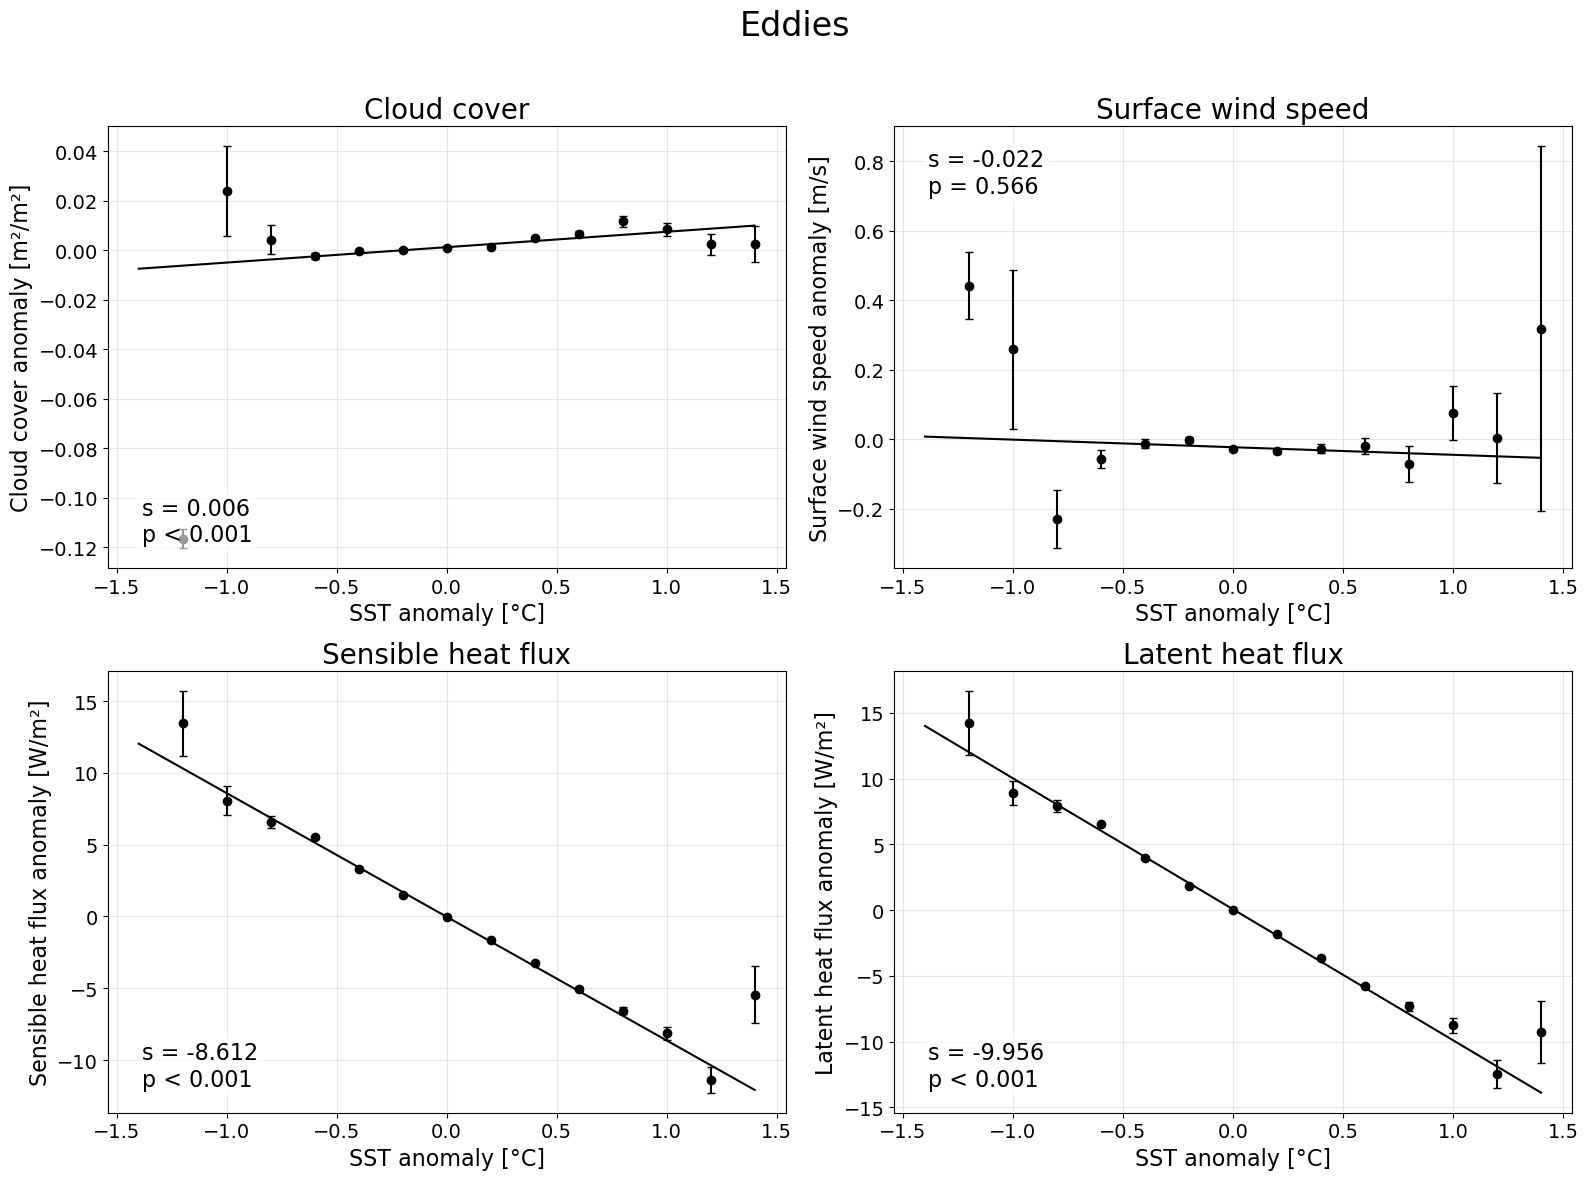

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# Example variables (replace these with your actual data)
variables = ["clt", "sfcwind", "hfss", "hfls"]
titles = [
    "Cloud cover anomaly [m²/m²]",
    "Surface wind speed anomaly [m/s]",
    "Sensible heat flux anomaly [W/m²]",
    "Latent heat flux anomaly [W/m²]"
]

pvals = {
    "clt": "p < 0.001",
    "sfcwind": "p = 0.566",
    "hfss": "p < 0.001",
    "hfls": "p < 0.001"
}


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # easier indexing

for i, var in enumerate(variables):
    ax = axes[i]
    
    mean_week = globals()[f"{var}_mean_week"].values
    sem_week = globals()[f"{var}_sem_week"].values
    res_week = globals()[f"res_week_{var}"]
    
    # Plot binned mean with error bars
    ax.errorbar(
        bin_centers,
        mean_week,
        yerr=sem_week,
        fmt="o",
        capsize=3,
        color="black"
    )
    
    # Regression line
    x_line = np.linspace(bin_centers.min(), bin_centers.max(), 200)
    ax.plot(
        x_line,
        res_week.intercept + res_week.slope * x_line,
        "k-",
        lw=1.5
    )
    
    # Slope and p-value text in the top-right or top-left

    if i == 0:  # TOP ROW
        ax.text(
            0.05, 0.05,     
            f"s = {res_week.slope:.3f}\n"
            f"{pvals[var]}",
            transform=ax.transAxes,
            fontsize=16,
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )

    elif i == 1:  # TOP ROW
        ax.text(
            0.05, 0.95,     
            f"s = {res_week.slope:.3f}\n"
            f"{pvals[var]}",
            transform=ax.transAxes,
            fontsize=16,
            va="top",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    

    else:  # BOTTOM ROW
        ax.text(
            0.05, 0.05,
            f"s = {res_week.slope:.3f}\n"
            f"{pvals[var]}",
            transform=ax.transAxes,
            fontsize=16,
            va="bottom",
            ha="left",
            bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
        )
    
    
    # Labels and grid
    clean_title = titles[i].split('anomaly')[0].strip()
    ax.set_title(clean_title, fontsize=20)
    ax.set_xlabel("SST anomaly [°C]", fontsize=16)
    ax.set_ylabel(titles[i], fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="both", labelsize=14)

plt.suptitle("Eddies", fontsize = 24)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("eddy_obs_sstbins.pdf", bbox_inches="tight")
plt.show()
